In [1]:
import pandas as pd
import requests
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
CURATED = PROJECT_ROOT / "data" / "curated"

CURATED.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)

/Users/zikrazuhuree/Documents/project-2-group-buy-now-pay-later-industry-project-21/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


/Users/zikrazuhuree/Documents/project-2-group-buy-now-pay-later-industry-project-21


In [3]:
# generating external dataset
records = []
offset = 0
batch_size = 1000

while True:
    params = {
        "where": "1=1",
        "outFields": (
            "objectid,poa_code_2021,poa_name_2021,urp,"
            "irsad_score,irsad_aus_decile,"
            "irsd_score,irsd_aus_decile,"
            "ier_score,ier_aus_decile,"
            "ieo_score,ieo_aus_decile,"
            "quality"
        ),
        "returnGeometry": "false",
        "f": "json",
        "resultOffset": offset,
        "resultRecordCount": batch_size,
        "orderByFields": "objectid"
    }

    response = requests.get(url, params=params)
    response.raise_for_status()

    batch = [
        feature["attributes"]
        for feature in response.json()["features"]
    ]

    records.extend(batch)

    print(f"Downloaded {len(records):,} records...")

    if len(batch) < batch_size:
        break

    offset += batch_size

seifa_raw = pd.DataFrame(records)

print("\nFinal shape:", seifa_raw.shape)
display(seifa_raw.head())

Downloaded 1,000 records...
Downloaded 2,000 records...
Downloaded 2,644 records...

Final shape: (2644, 13)


,objectid,poa_code_2021,poa_name_2021,urp,irsad_score,irsad_aus_decile,irsd_score,irsd_aus_decile,ier_score,ier_aus_decile,ieo_score,ieo_aus_decile,quality
0,1,0800,0800,7149.0,1084.261433,9.0,1064.349794,9.0,921.395254,1.0,1089.647675,9.0,NaN
1,2,0810,0810,34330.0,1036.266842,8.0,1026.802176,7.0,992.867218,5.0,1047.620794,8.0,NaN
2,3,0812,0812,18634.0,981.720979,6.0,981.137162,4.0,977.777285,4.0,978.905626,6.0,NaN
3,4,0820,0820,19920.0,1075.721877,9.0,1061.250806,9.0,981.896356,4.0,1076.326539,9.0,NaN
4,5,0822,0822,25304.0,760.604459,1.0,601.552207,1.0,630.686758,1.0,885.789899,1.0,NaN


In [ ]:
# clean clean clean!!!!!!
seifa = seifa_raw.copy()

# rename columns for clarity and easier joining
seifa = seifa.rename(columns={
    "poa_code_2021": "postcode",
    "poa_name_2021": "postal_area",
    "urp": "population"
})

# postcode is an identifier, so keep it as a 4-digit string
seifa["postcode"] = (
    seifa["postcode"]
    .astype("string")
    .str.strip()
    .str.zfill(4)
)

# columns that should be numeric
numeric_cols = [
    "population",
    "irsad_score",
    "irsad_aus_decile",
    "irsd_score",
    "irsd_aus_decile",
    "ier_score",
    "ier_aus_decile",
    "ieo_score",
    "ieo_aus_decile"
]

for col in numeric_cols:
    seifa[col] = pd.to_numeric(seifa[col], errors="coerce")

# API identifier is not analytically useful
seifa = seifa.drop(columns=["objectid"])

# Drop quality only if it is completely empty
if seifa["quality"].isna().all():
    seifa = seifa.drop(columns=["quality"])

# Guarantee one row per postcode
seifa = seifa.drop_duplicates(subset="postcode")

print("Cleaned shape:", seifa.shape)
display(seifa.head())

Cleaned shape: (2644, 12)


,postcode,postal_area,population,irsad_score,irsad_aus_decile,irsd_score,irsd_aus_decile,ier_score,ier_aus_decile,ieo_score,ieo_aus_decile,quality
0,0800,0800,7149.0,1084.261433,9.0,1064.349794,9.0,921.395254,1.0,1089.647675,9.0,NaN
1,0810,0810,34330.0,1036.266842,8.0,1026.802176,7.0,992.867218,5.0,1047.620794,8.0,NaN
2,0812,0812,18634.0,981.720979,6.0,981.137162,4.0,977.777285,4.0,978.905626,6.0,NaN
3,0820,0820,19920.0,1075.721877,9.0,1061.250806,9.0,981.896356,4.0,1076.326539,9.0,NaN
4,0822,0822,25304.0,760.604459,1.0,601.552207,1.0,630.686758,1.0,885.789899,1.0,NaN


In [5]:
print("Number of rows:", len(seifa))
print("Unique postcodes:", seifa["postcode"].nunique())
print("Duplicate postcodes:", seifa["postcode"].duplicated().sum())

print("\nMissing values:")
print(seifa.isna().sum())

print("\nInvalid postcode formats:")
print((~seifa["postcode"].str.match(r"^\d{4}$")).sum())
# cheacking whether the cleaning worked icl

Number of rows: 2644
Unique postcodes: 2644
Duplicate postcodes: 0

Missing values:
postcode               0
postal_area            0
population            20
irsad_score           20
irsad_aus_decile      20
irsd_score            20
irsd_aus_decile       20
ier_score             20
ier_aus_decile        20
ieo_score             17
ieo_aus_decile        17
quality             2477
dtype: int64

Invalid postcode formats:
1


In [6]:
# Rows with missing SEIFA information
score_cols = [
    "population",
    "irsad_score",
    "irsad_aus_decile",
    "irsd_score",
    "irsd_aus_decile",
    "ier_score",
    "ier_aus_decile",
    "ieo_score",
    "ieo_aus_decile"
]

missing_rows = seifa[
    seifa[score_cols].isna().any(axis=1)
]

print("Rows with at least one missing SEIFA field:", len(missing_rows))

display(
    missing_rows[
        ["postcode", "postal_area"] + score_cols
    ]
)
#checking cause there was an invalid postcode

Rows with at least one missing SEIFA field: 20


,postcode,postal_area,population,irsad_score,irsad_aus_decile,irsd_score,irsd_aus_decile,ier_score,ier_aus_decile,ieo_score,ieo_aus_decile
268,2308,2308,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
485,2624,2624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,997.545762,7.0
523,2678,2678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
725,3062,3062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1268,3852,3852,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1879,5111,5111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1914,5160,5160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,882.406152,1.0
2139,5950,5950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2198,6068,6068,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2213,6090,6090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
invalid_postcode_rows = seifa[
    ~seifa["postcode"].str.match(r"^\d{4}$", na=False)
]

display(invalid_postcode_rows)

,postcode,postal_area,population,irsad_score,irsad_aus_decile,irsd_score,irsd_aus_decile,ier_score,ier_aus_decile,ieo_score,ieo_aus_decile,quality
2643,ZZZZ,Outside Australia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# found the weird one so will probs drop that but checking quality
print(seifa["quality"].value_counts(dropna=False))

quality
NaN    2477
1.0     167
Name: count, dtype: int64


In [9]:
seifa = seifa[seifa["postcode"].str.match(r"^\d{4}$", na=False)].copy()

print("Shape after removing non-postcode records:", seifa.shape)

Shape after removing non-postcode records: (2643, 12)


In [10]:
seifa = seifa.rename(columns={"quality": "poa_quality_flag"})

In [11]:
# outlier analysis since we dealt with missing data!!!
continuous_cols = [
    "population",
    "irsad_score",
    "irsd_score",
    "ier_score",
    "ieo_score"
]

outlier_results = []

for col in continuous_cols:
    x = seifa[col].dropna()

    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outliers = ((x < lower) | (x > upper)).sum()

    outlier_results.append({
        "variable": col,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
        "outlier_count": n_outliers,
        "outlier_percent": round(n_outliers / len(x) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_results)

display(outlier_summary)

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
0,population,709.25,13986.00,13276.75,-19205.88,33901.12,160,6.10
1,irsad_score,931.32,1035.03,103.71,775.75,1190.60,13,0.50
2,irsd_score,957.14,1047.16,90.01,822.12,1182.18,63,2.40
3,ier_score,963.08,1043.81,80.73,841.99,1164.90,55,2.10
4,ieo_score,920.93,1034.52,113.58,750.56,1204.89,2,0.08


Matplotlib is building the font cache; this may take a moment.


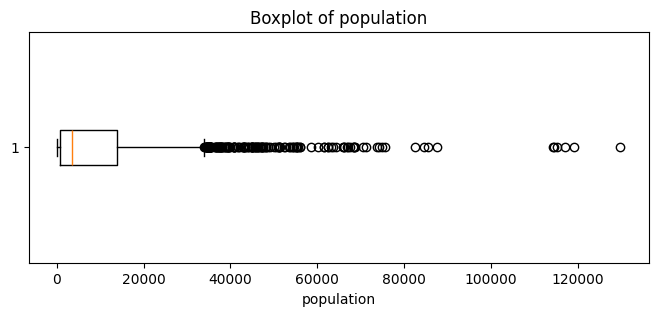

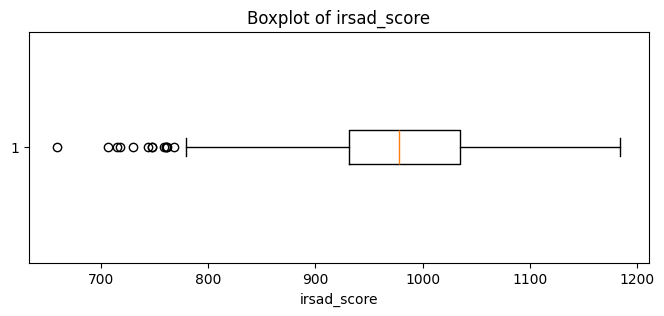

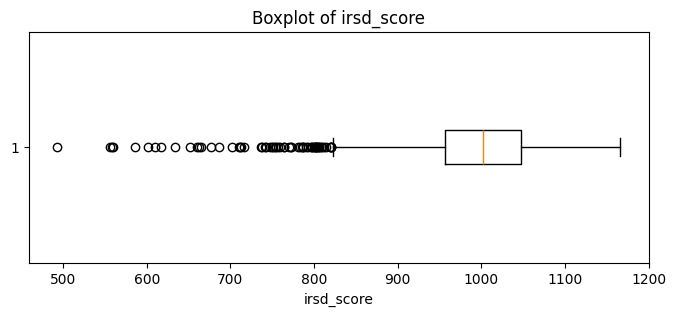

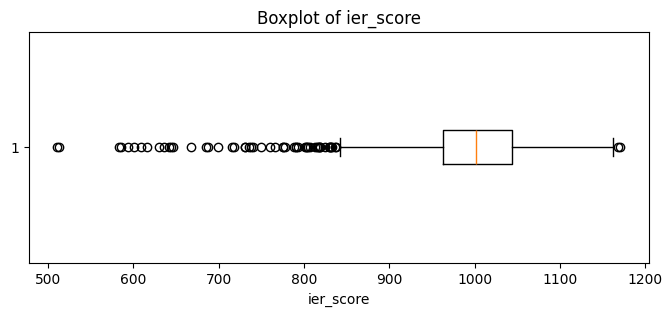

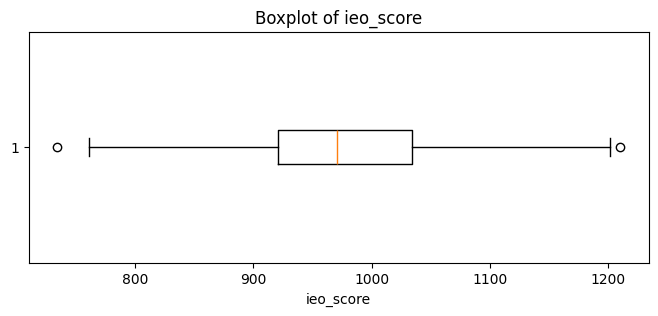

In [12]:
# visualise outliers
import matplotlib.pyplot as plt

for col in continuous_cols:
    plt.figure(figsize=(8, 3))
    plt.boxplot(seifa[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [13]:
# okay outliers are there but they arre not overtly impacting cause census data can be unreliable so im not going to label them as missing yet
continuous_cols = [
    "population",
    "irsad_score",
    "irsd_score",
    "ier_score",
    "ieo_score"
]

for col in continuous_cols:
    q1 = seifa[col].quantile(0.25)
    q3 = seifa[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    seifa[f"{col}_outlier"] = (
        ((seifa[col] < lower) | (seifa[col] > upper))
        & seifa[col].notna()
    )

In [14]:
# removing ABS special geography that cannot map to an Australian postcode
seifa = seifa[
    seifa["postcode"].str.match(r"^\d{4}$", na=False)
].copy()

# renaming quality field so its purpose is explicit
seifa = seifa.rename(
    columns={"quality": "poa_quality_flag"}
)

# confirming postcode is unique
assert seifa["postcode"].is_unique

print("Final cleaned shape:", seifa.shape)
print("\nMissing values:")
print(seifa.isna().sum())

Final cleaned shape: (2643, 17)

Missing values:
postcode                  0
postal_area               0
population               19
irsad_score              19
irsad_aus_decile         19
irsd_score               19
irsd_aus_decile          19
ier_score                19
ier_aus_decile           19
ieo_score                16
ieo_aus_decile           16
poa_quality_flag       2476
population_outlier        0
irsad_score_outlier       0
irsd_score_outlier        0
ier_score_outlier         0
ieo_score_outlier         0
dtype: int64


In [15]:
# mapping it onto postcodes!! yay!!
TABLES = PROJECT_ROOT / "data" / "tables"

consumers = pd.read_csv(
    TABLES / "tbl_consumer.csv",
    sep="|",
    dtype={"postcode": "string"}
)

consumer_geo = consumers[
    ["consumer_id", "postcode"]
].copy()

consumer_geo["postcode"] = (
    consumer_geo["postcode"]
    .astype("string")
    .str.strip()
    .str.zfill(4)
)

consumer_seifa = consumer_geo.merge(
    seifa,
    on="postcode",
    how="left",
    validate="many_to_one",
    indicator=True
)

In [16]:
# calculating coverage
total = len(consumer_seifa)
matched = (consumer_seifa["_merge"] == "both").sum()
unmatched = (consumer_seifa["_merge"] == "left_only").sum()

print(f"Total consumers:     {total:,}")
print(f"Matched consumers:   {matched:,}")
print(f"Unmatched consumers: {unmatched:,}")
print(f"Match rate:          {matched / total * 100:.2f}%")

Total consumers:     499,999
Matched consumers:   416,818
Unmatched consumers: 83,181
Match rate:          83.36%


In [17]:
# inspecting match rate
unmatched_postcodes = (
    consumer_seifa.loc[
        consumer_seifa["_merge"] == "left_only",
        "postcode"
    ]
    .value_counts()
    .reset_index()
)

unmatched_postcodes.columns = [
    "postcode",
    "consumer_count"
]

display(unmatched_postcodes.head(20))

,postcode,consumer_count
0,6231,196
1,6917,193
2,3724,188
3,1162,187
4,6831,186
5,1157,186
6,1132,185
7,2901,185
8,1121,185
9,1196,185


In [18]:
# forgot to do postcode coverage oops but yay 83.36% match rate
unique_consumer_postcodes = consumer_geo["postcode"].nunique()

matched_postcodes = consumer_seifa.loc[
    consumer_seifa["_merge"] == "both",
    "postcode"
].nunique()

unmatched_unique_postcodes = consumer_seifa.loc[
    consumer_seifa["_merge"] == "left_only",
    "postcode"
].nunique()

print(f"Unique BNPL postcodes:     {unique_consumer_postcodes:,}")
print(f"Matched unique postcodes:  {matched_postcodes:,}")
print(f"Unmatched postcodes:       {unmatched_unique_postcodes:,}")
print(
    f"Postcode coverage:         "
    f"{matched_postcodes / unique_consumer_postcodes * 100:.2f}%"
)

Unique BNPL postcodes:     3,167
Matched unique postcodes:  2,640
Unmatched postcodes:       527
Postcode coverage:         83.36%


In [ ]:
# distinguishing between missing data for consumers and postcodes
score_cols = [
    "population",
    "irsad_score",
    "irsad_aus_decile",
    "irsd_score",
    "irsd_aus_decile",
    "ier_score",
    "ier_aus_decile",
    "ieo_score",
    "ieo_aus_decile"
]

matched_rows = consumer_seifa[
    consumer_seifa["_merge"] == "both"
]

print("Missing values among successfully matched consumers:\n")

for col in score_cols:
    n_missing = matched_rows[col].isna().sum()
    pct_missing = n_missing / len(matched_rows) * 100

    print(f"{col:20s}: {n_missing:7,} ({pct_missing:.2f}%)")

Missing values among successfully matched consumers:

population          :   2,693 (0.65%)
irsad_score         :   2,693 (0.65%)
irsad_aus_decile    :   2,693 (0.65%)
irsd_score          :   2,693 (0.65%)
irsd_aus_decile     :   2,693 (0.65%)
ier_score           :   2,693 (0.65%)
ier_aus_decile      :   2,693 (0.65%)
ieo_score           :   2,221 (0.53%)
ieo_aus_decile      :   2,221 (0.53%)


In [20]:
# cleaning external table for the group's ETL
seifa.to_csv(
    CURATED / "abs_seifa_2021_poa_clean.csv",
    index=False
)

# auditing table showing postcodes that failed to map
unmatched_postcodes.to_csv(
    CURATED / "seifa_unmatched_bnpl_postcodes.csv",
    index=False
)

print("Files saved successfully.")

Files saved successfully.


External Data Mapping and Data Quality

The cleaned ABS SEIFA 2021 dataset contained 2,643 valid Australian Postal Area records after removing the non-geographic ZZZZ (“Outside Australia”) record. Limited missingness remained in the official source: 19 Postal Areas lacked population, IRSAD, IRSD and IER measures, while 16 lacked IEO measures. These values were retained as missing rather than imputed because artificial socioeconomic values could misrepresent areas for which no reliable score was available.

Continuous-variable outliers were assessed using the 1.5 × IQR rule. Outliers were identified for population (160; 6.10%), IRSAD (13; 0.50%), IRSD (63; 2.40%), IER (55; 2.10%) and IEO (2; 0.08%). They were retained because the observations plausibly reflect genuine differences in Postal Area population and socioeconomic conditions rather than data-entry errors.

Joining BNPL consumers to SEIFA by four-digit postcode matched 416,818 of 499,999 consumers (83.36%), leaving 83,181 consumers (16.64%) unmatched. This is consistent with a known limitation of ABS Postal Areas: POAs approximate postcodes and exclude some non-mappable and non-street-delivery postcodes. Unmatched consumers were therefore retained with missing SEIFA fields rather than assigned an arbitrary socioeconomic profile.